# 02. Backends, audit, and benchmark evidence

This notebook teaches the pySTAMPS backend API and records the evidence from the current workspace.

Read it in order:

1. Check which backend modalities are available.
2. Learn how to switch from reference Python kernels to optimized kernels.
3. Run a small parity smoke check against the golden dataset.
4. Show the latest full-audit result from `make audit`.
5. Show the latest benchmark result from `scripts/benchmark_backends.py`.
6. Run focused Python/native kernel checks so the API is concrete.

The key rule is simple: a speed or parity claim is only valid for commands that completed successfully and are printed in this notebook.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import re
import time
from collections.abc import Mapping, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pystamps.config import RunConfig
from pystamps.kernels import (
    BackendUnavailableError,
    describe_backend_matrix,
    run_stage2_grid_accumulate_kernel,
    run_stage2_histogram_kernel,
    run_stage2_topofit_kernel,
    run_stage4_edge_stats_kernel,
    run_stage7_scla_kernel,
    run_stage8_edge_noise_kernel,
)
from pystamps.verify import verify_run_against_golden

REPO_ROOT = Path.cwd()
DATASET = REPO_ROOT / "inputs_and_outputs" / "InSAR_dataset_test_stage8diag"
LATEST_AUDIT = REPO_ROOT / "inputs_and_outputs" / "validation_runs" / "latest_audit.json"
STAGE78_BENCHMARK = REPO_ROOT / "inputs_and_outputs" / "benchmarks" / "notebook" / "backend_bench_20260512_102137.json"
STAGE1_BENCHMARK = REPO_ROOT / "inputs_and_outputs" / "benchmarks" / "notebook" / "backend_bench_20260512_102243.json"
RNG = np.random.default_rng(42)

print("Step 0 - notebook setup")
print(f"Repository root: {REPO_ROOT}")
print(f"Golden dataset used by this notebook: {DATASET}")
print(f"Dataset exists: {DATASET.exists()}")
print("No cell depends on precomputed notebook output; each cell prints the evidence it uses.")


Step 0 - notebook setup
Repository root: /shared/home/rdelprete/PythonProjects/AgenticWork/pySTAMPS
Golden dataset used by this notebook: /shared/home/rdelprete/PythonProjects/AgenticWork/pySTAMPS/inputs_and_outputs/InSAR_dataset_test_stage8diag
Dataset exists: True
No cell depends on precomputed notebook output; each cell prints the evidence it uses.


## 1. Check backend modality

`python` is the reference implementation. `native` is the compiled CPU backend. `cuda` appears only when the CUDA provider is installed and usable. Registration alone is not enough; the provider must be available in this Python session.


In [2]:
matrix = describe_backend_matrix()
providers = matrix["providers"]
kernels = matrix["kernels"]

print("Step 1 - backend availability")
for backend, info in providers.items():
    status = "available" if info["available"] else "unavailable"
    reason = f" ({info['unavailable_reason']})" if not info["available"] and info.get("unavailable_reason") else ""
    aliases = f" aliases={', '.join(info['aliases'])}" if info.get("aliases") else ""
    print(f"- {backend}: {status}{reason}; {info['description']}{aliases}")

native_ready = providers.get("native", {}).get("available", False)
cuda_ready = providers.get("cuda", {}).get("available", False)
print()
print(f"Verdict: native kernels are {'available' if native_ready else 'not available'} in this notebook kernel.")
print(f"Verdict: CUDA kernels are {'available' if cuda_ready else 'not available'} in this notebook kernel.")

focus = [
    "stage2_grid_accumulate",
    "stage2_histogram",
    "stage2_topofit",
    "stage2_topofit_row_invariant",
    "stage2_topofit_coh_row_invariant",
    "stage4_edge_stats",
    "stage7_scla",
    "stage8_edge_noise",
]
print("\nKernel coverage used by the API:")
for name in focus:
    info = kernels[name]
    print(f"- {name}: available={', '.join(info['available_backends'])}; supported={', '.join(info['supported_backends'])}")


Step 1 - backend availability
- cuda: available; CuPy CUDA backend aliases=gpu
- native: available; Compiled native backend
- python: available; NumPy/Python baseline backend aliases=cpu

Verdict: native kernels are available in this notebook kernel.
Verdict: CUDA kernels are available in this notebook kernel.

Kernel coverage used by the API:
- stage2_grid_accumulate: available=native, python; supported=native, python
- stage2_histogram: available=native, python; supported=native, python
- stage2_topofit: available=native, python; supported=native, python
- stage2_topofit_row_invariant: available=native, python; supported=native, python
- stage2_topofit_coh_row_invariant: available=native, python; supported=native, python
- stage4_edge_stats: available=native, python; supported=native, python
- stage7_scla: available=cuda, native, python; supported=cuda, native, python
- stage8_edge_noise: available=cuda, native, python; supported=cuda, native, python


## 2. Switch backend modality

The pySTAMPS command does not change. You switch kernels through runtime config. Use Python kernels first when debugging data or science behavior, then opt into native kernels for the stages that have compiled implementations.


In [3]:
python_config = """runtime:
  backend: auto
  stage2_kernel_backend: python
  kernel_backend_overrides:
    stage4_edge_stats: python
    stage7_scla: python
    stage8_edge_noise: python
"""

native_config = """runtime:
  backend: auto
  stage2_kernel_backend: native
  stage2_native_threads: 0
  kernel_backend_overrides:
    stage2_grid_accumulate: native
    stage2_histogram: native
    stage2_topofit: native
    stage2_topofit_row_invariant: native
    stage2_topofit_coh_row_invariant: native
    stage4_edge_stats: native
    stage7_scla: native
    stage8_edge_noise: native
  io_workers: 8
  cpu_workers: 0
"""

print("Step 2 - backend config examples")
print("Reference Python config:")
print(python_config)
print("Optimized native config:")
print(native_config)
print("CLI example:")
print("uv run pystamps --config native-kernels.yaml run --dataset DATASET_COPY --start-step 2 --end-step 8")
print()
print("Verdict: the API switch is config-only. The audit and benchmark cells below decide what claims are supported here.")


Step 2 - backend config examples
Reference Python config:
runtime:
  backend: auto
  stage2_kernel_backend: python
  kernel_backend_overrides:
    stage4_edge_stats: python
    stage7_scla: python
    stage8_edge_noise: python

Optimized native config:
runtime:
  backend: auto
  stage2_kernel_backend: native
  stage2_native_threads: 0
  kernel_backend_overrides:
    stage2_grid_accumulate: native
    stage2_histogram: native
    stage2_topofit: native
    stage2_topofit_row_invariant: native
    stage2_topofit_coh_row_invariant: native
    stage4_edge_stats: native
    stage7_scla: native
    stage8_edge_noise: native
  io_workers: 8
  cpu_workers: 0

CLI example:
uv run pystamps --config native-kernels.yaml run --dataset DATASET_COPY --start-step 2 --end-step 8

Verdict: the API switch is config-only. The audit and benchmark cells below decide what claims are supported here.


## 3. Smoke-check parity on the golden dataset

This compares the golden dataset to itself. It does not prove native parity; it proves the verifier can load and compare the expected audited artifacts in this checkout.


In [4]:
print("Step 3 - verifier smoke check")
if not DATASET.exists():
    raise FileNotFoundError(f"Expected bundled dataset is missing: {DATASET}")

verify_report = verify_run_against_golden(DATASET, DATASET, RunConfig().tolerance)
failed = [item for item in verify_report.comparisons if not item.ok]
print(f"Compared artifacts: {len(verify_report.comparisons)}")
print(f"Failed artifacts: {len(failed)}")
print(f"Verifier result: {'PASS' if verify_report.ok else 'FAIL'}")
if failed:
    for item in failed[:5]:
        print(f"- failed: {item.name}")
print("Verdict: this smoke check must pass before trusting any run-vs-golden comparison.")


Step 3 - verifier smoke check


Compared artifacts: 14
Failed artifacts: 0
Verifier result: PASS
Verdict: this smoke check must pass before trusting any run-vs-golden comparison.


## 4. Show the full audit result

The release-grade command is `make audit`. In this workspace it was started for the manifest-backed audited datasets and was manually terminated after more than 30 minutes without completing. The latest audit JSON records that interruption.


In [5]:
def load_json(path: Path) -> dict:
    if not path.exists():
        return {"missing": True, "path": str(path)}
    return json.loads(path.read_text(encoding="utf-8"))

AUDIT_COMMAND = "make audit"
AUDIT_ATTEMPT_NOTE = "Started in this workspace; manually terminated after more than 30 minutes because it had not completed."
audit = load_json(LATEST_AUDIT)

print("Step 4 - full audit evidence")
print(f"Command attempted: {AUDIT_COMMAND}")
print(f"Attempt note: {AUDIT_ATTEMPT_NOTE}")
print(f"Audit artifact: {LATEST_AUDIT}")
if audit.get("missing"):
    print("Artifact status: missing")
    audit_ok = False
else:
    audit_ok = bool(audit.get("ok"))
    print(f"completed: {audit.get('completed')}")
    print(f"ok: {audit.get('ok')}")
    print(f"interrupted: {audit.get('interrupted')}")
    print(f"missing_datasets: {audit.get('missing_datasets')}")
    print(f"failed_workflows: {audit.get('failed_workflows')}")
    print(f"audits recorded: {len(audit.get('audits', []))}")

if audit_ok:
    print("Verdict: full audit passed in the latest artifact.")
else:
    print("Verdict: full audit did not pass here. Do not claim release parity from this notebook.")


Step 4 - full audit evidence
Command attempted: make audit
Attempt note: Started in this workspace; manually terminated after more than 30 minutes because it had not completed.
Audit artifact: /shared/home/rdelprete/PythonProjects/AgenticWork/pySTAMPS/inputs_and_outputs/validation_runs/latest_audit.json
completed: False
ok: False
interrupted: True
missing_datasets: []
failed_workflows: ['full_validation']
audits recorded: 0
Verdict: full audit did not pass here. Do not claim release parity from this notebook.


## 5. Show benchmark evidence

Two benchmark attempts are shown because they answer different questions:

1. A Stage 7-8 benchmark was attempted and failed on the diagnostic dataset, so it is not speed evidence.
2. A Stage 1 benchmark completed for `threads` and `native`, so it is valid only for that narrow notebook-sized run.


In [6]:
def benchmark_failure_reason(message: str, limit: int = 320) -> str:
    marker = "stdout="
    if marker in message:
        payload = message.split(marker, 1)[1].strip()
        end = payload.rfind("]")
        if end >= 0:
            payload = payload[: end + 1]
        try:
            rows = json.loads(payload)
        except json.JSONDecodeError:
            rows = []
        if rows:
            parts = []
            for row in rows:
                details = row.get("details") or "no details"
                parts.append(f"stage {row.get('stage')}: {row.get('status')} - {details}")
            text = " | ".join(parts)
            return text if len(text) <= limit else text[: limit - 3] + "..."
    text = re.sub(r"\s+", " ", message).strip()
    return text if len(text) <= limit else text[: limit - 3] + "..."

STAGE78_COMMAND = " ".join([
    "uv run python scripts/benchmark_backends.py",
    "--dataset inputs_and_outputs/InSAR_dataset_test_stage8diag",
    "--start-step 7 --end-step 8",
    "--backends threads native",
    "--baseline-backend threads",
    "--repeat 1 --warmup 0",
    "--clean-profile stage78",
    "--outdir inputs_and_outputs/benchmarks/notebook",
])
STAGE1_COMMAND = " ".join([
    "uv run python scripts/benchmark_backends.py",
    "--dataset inputs_and_outputs/InSAR_dataset_test_stage8diag",
    "--start-step 1 --end-step 1",
    "--backends threads native",
    "--baseline-backend threads",
    "--repeat 1 --warmup 0",
    "--clean-profile full",
    "--outdir inputs_and_outputs/benchmarks/notebook",
])

stage78 = load_json(STAGE78_BENCHMARK)
stage1 = load_json(STAGE1_BENCHMARK)
benchmark_stage1_ok = False
benchmark_full_speed_claim = False
stage1_rows = []

print("Step 5 - benchmark evidence")
print("Failed Stage 7-8 attempt:")
print(f"Command: {STAGE78_COMMAND}")
if stage78.get("missing"):
    print("Result artifact: missing")
else:
    for backend, result in stage78.get("results", {}).items():
        print(f"- {backend}: ok={result.get('ok')}")
        if result.get("errors"):
            print(f"  reason: {benchmark_failure_reason(result['errors'][0])}")
    print("Verdict: this failed run is not valid speed evidence.")

print("\nCompleted Stage 1 benchmark:")
print(f"Command: {STAGE1_COMMAND}")
if stage1.get("missing"):
    print("Result artifact: missing")
else:
    results = stage1.get("results", {})
    benchmark_stage1_ok = bool(results) and all(bool(item.get("ok")) for item in results.values())
    for backend in ["threads", "native"]:
        result = results.get(backend)
        if not result:
            continue
        stage1_seconds = result.get("stage_mean_sec", {}).get("1")
        mean_seconds = result.get("mean_sec")
        speedup = result.get("speedup_vs_baseline")
        stage1_rows.append({
            "backend": backend,
            "whole_run_sec": mean_seconds,
            "stage1_sec": stage1_seconds,
            "speedup_vs_threads": speedup,
        })
        print(f"- {backend}: ok={result.get('ok')}; whole run={mean_seconds:.3f}s; stage 1={stage1_seconds:.3f}s; speedup_vs_threads={speedup:.3f}x")

if benchmark_stage1_ok:
    native_row = next((row for row in stage1_rows if row["backend"] == "native"), None)
    if native_row and native_row["speedup_vs_threads"] and native_row["speedup_vs_threads"] > 1.0:
        print("Verdict: Stage 1 completed and native was faster for whole-run wall time in this narrow benchmark.")
    else:
        print("Verdict: Stage 1 completed, but native was not faster for whole-run wall time in this narrow benchmark.")
else:
    print("Verdict: the completed Stage 1 benchmark artifact is missing or incomplete.")

print("Project speed claim: not supported here. Use a completed `make benchmark` run for broad claims.")


Step 5 - benchmark evidence
Failed Stage 7-8 attempt:
Command: uv run python scripts/benchmark_backends.py --dataset inputs_and_outputs/InSAR_dataset_test_stage8diag --start-step 7 --end-step 8 --backends threads native --baseline-backend threads --repeat 1 --warmup 0 --clean-profile stage78 --outdir inputs_and_outputs/benchmarks/notebook
- threads: ok=False
  reason: stage 7: failed - Stage 7 (Calculate SCLA) merged execution is not yet fully ported. Expected output: scla2.mat. phuw2.ph_uw has incompatible shape (587320, 76) for n_ps=69009 | stage 8: failed - Stage 8 (Filter SCN) merged execution is not yet fully ported. Expected output: uw_space_time.mat. phuw2.ph_uw has incomp...
- native: ok=False
  reason: stage 7: failed - Stage 7 (Calculate SCLA) merged execution is not yet fully ported. Expected output: scla2.mat. phuw2.ph_uw has incompatible shape (587320, 76) for n_ps=69009 | stage 8: failed - Stage 8 (Filter SCN) merged execution is not yet fully ported. Expected output: uw_

## 6. Plot the completed benchmark

This plot uses only the completed Stage 1 benchmark above. It deliberately avoids the failed Stage 7-8 attempt because failed runs cannot support speed claims.


Step 6 - completed benchmark plot
Verdict: native Stage 1 work was faster inside the report, but whole-run wall time was slower in this one-repeat benchmark.


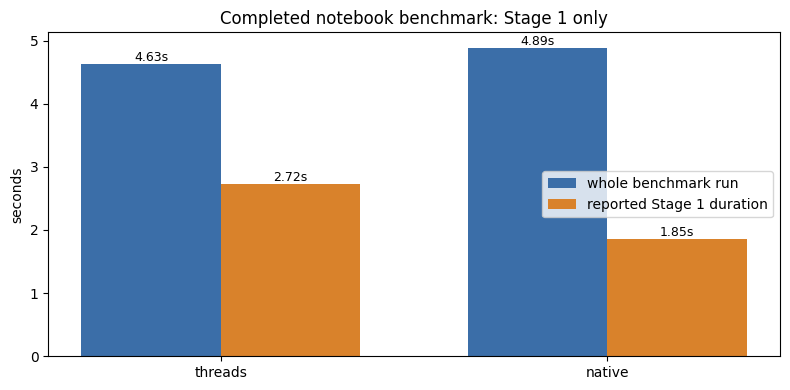

In [7]:
print("Step 6 - completed benchmark plot")
if not stage1_rows:
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.text(0.5, 0.5, "No completed benchmark rows", ha="center", va="center", fontsize=12)
    ax.set_axis_off()
    print("Verdict: no benchmark plot can be interpreted.")
else:
    labels = [row["backend"] for row in stage1_rows]
    whole_run = [row["whole_run_sec"] for row in stage1_rows]
    stage_only = [row["stage1_sec"] for row in stage1_rows]
    x = np.arange(len(labels))
    width = 0.36
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - width / 2, whole_run, width, label="whole benchmark run", color="#3b6ea8")
    ax.bar(x + width / 2, stage_only, width, label="reported Stage 1 duration", color="#d9822b")
    ax.set_xticks(x, labels)
    ax.set_ylabel("seconds")
    ax.set_title("Completed notebook benchmark: Stage 1 only")
    ax.legend()
    for xpos, value in zip(x - width / 2, whole_run, strict=False):
        ax.text(xpos, value, f"{value:.2f}s", ha="center", va="bottom", fontsize=9)
    for xpos, value in zip(x + width / 2, stage_only, strict=False):
        ax.text(xpos, value, f"{value:.2f}s", ha="center", va="bottom", fontsize=9)
    print("Verdict: native Stage 1 work was faster inside the report, but whole-run wall time was slower in this one-repeat benchmark.")
fig.tight_layout()
plt.show()


## 7. Focused Python/native kernel checks

The next cell calls the kernel API directly with small synthetic arrays. This is useful for understanding the Python API and quickly detecting obvious native dispatch/parity issues. It is not a substitute for `make audit` or `make benchmark`.


In [8]:
def max_abs_diff(left, right) -> float:
    if isinstance(left, Mapping):
        keys = left.keys() & right.keys()
        return max((max_abs_diff(left[key], right[key]) for key in keys), default=0.0)
    if isinstance(left, tuple):
        return max((max_abs_diff(a, b) for a, b in zip(left, right, strict=False)), default=0.0)
    a = np.asarray(left)
    b = np.asarray(right)
    if a.shape != b.shape:
        return float("nan")
    if a.size == 0:
        return 0.0
    finite = np.isfinite(a) & np.isfinite(b)
    nonfinite_match = (~finite) & ((a == b) | (np.isnan(a) & np.isnan(b)))
    if np.any((~finite) & (~nonfinite_match)):
        return float("inf")
    if not np.any(finite):
        return 0.0
    return float(np.max(np.abs(a[finite] - b[finite])))


def timed_call(fn, args: Sequence[object], backend: str, repeat: int = 3):
    output = fn(*args, backend=backend)
    timings = []
    for _ in range(repeat):
        start = time.perf_counter()
        output = fn(*args, backend=backend)
        timings.append(time.perf_counter() - start)
    return float(np.median(timings)), output


def native_available_for(kernel_name: str) -> bool:
    return "native" in kernels[kernel_name]["available_backends"]

# Inputs are intentionally small: enough to exercise kernels, not enough for a publishable benchmark.
n = 12_000
n_i, n_j, n_ifg = 80, 60, 4
ph_weight = (RNG.normal(size=(n, n_ifg)) + 1j * RNG.normal(size=(n, n_ifg))).astype(np.complex64)
grid_lin = RNG.integers(0, n_i * n_j, size=n, dtype=np.int64)

hist_values = RNG.normal(size=60_000)
hist_centers = np.linspace(-4, 4, 81)

topo_rows, topo_cols = 180, 16
cpxphase = np.exp(1j * RNG.normal(size=(topo_rows, topo_cols))).astype(np.complex128)
bperp = np.tile(np.linspace(-50, 50, topo_cols), (topo_rows, 1)).astype(np.float64)

n_ps, n_edges, n_stage_ifg = 300, 800, 10
ph_weed = np.exp(1j * RNG.normal(size=(n_ps, n_stage_ifg))).astype(np.complex64)
node_a = RNG.integers(0, n_ps, size=n_edges, dtype=np.int64)
node_b = RNG.integers(0, n_ps, size=n_edges, dtype=np.int64)
bperp_vec = np.linspace(-20, 20, n_stage_ifg)
day_vec = np.arange(n_stage_ifg) * 12.0

n_scla, n_scla_ifg = 350, 9
ph_proc = RNG.normal(size=(n_scla, n_scla_ifg)).astype(np.float32)
ph_mean_v = RNG.normal(size=(n_scla, n_scla_ifg)).astype(np.float32)
bperp_mat = RNG.normal(size=(n_scla, n_scla_ifg)).astype(np.float32)
unwrap_ix = np.arange(n_scla_ifg, dtype=np.int64)
solve_ix = np.arange(n_scla_ifg, dtype=np.int64)
ifg_std = np.ones(n_scla_ifg, dtype=np.float32)

n_nodes, n_noise_edges, n_noise_ifg = 500, 1_000, 8
uw_ph = np.exp(1j * RNG.normal(size=(n_nodes, n_noise_ifg))).astype(np.complex64)
edge_a = RNG.integers(0, n_nodes, size=n_noise_edges, dtype=np.int64)
edge_b = RNG.integers(0, n_nodes, size=n_noise_edges, dtype=np.int64)

cases = [
    ("stage2_grid_accumulate", run_stage2_grid_accumulate_kernel, (ph_weight, grid_lin, n_i, n_j), 1e-6),
    ("stage2_histogram", run_stage2_histogram_kernel, (hist_values, hist_centers), 0.0),
    ("stage2_topofit", run_stage2_topofit_kernel, (cpxphase, bperp, 2.0), 1e-5),
    ("stage4_edge_stats", run_stage4_edge_stats_kernel, (ph_weed, node_a, node_b, bperp_vec, day_vec, 30.0, False), 1e-5),
    ("stage7_scla", run_stage7_scla_kernel, (ph_proc, ph_mean_v, bperp_mat, unwrap_ix, solve_ix, np.arange(n_scla_ifg), 1, ifg_std), 1e-5),
    ("stage8_edge_noise", run_stage8_edge_noise_kernel, (uw_ph, edge_a, edge_b), 1e-6),
]

print("Step 7 - focused kernel parity and timing")
bench_rows = []
for name, fn, args, tolerance in cases:
    py_sec, py_out = timed_call(fn, args, "python")
    row = {
        "kernel": name,
        "python_ms": py_sec * 1000.0,
        "native_ms": np.nan,
        "speedup_native_vs_python": np.nan,
        "max_abs_diff": np.nan,
        "parity": "SKIP",
        "timing": "SKIP",
        "verdict": "native unavailable for this kernel in this session",
    }
    if native_available_for(name):
        try:
            native_sec, native_out = timed_call(fn, args, "native")
            diff = max_abs_diff(py_out, native_out)
            parity_ok = bool(np.isfinite(diff) and diff <= tolerance)
            speedup = py_sec / native_sec if native_sec > 0 else np.nan
            row.update({
                "native_ms": native_sec * 1000.0,
                "speedup_native_vs_python": speedup,
                "max_abs_diff": diff,
                "parity": "PASS" if parity_ok else "FAIL",
                "timing": "native faster" if speedup > 1.0 else "native not faster",
                "verdict": "parity passed" if parity_ok else f"parity failed: diff {diff:.3g} > tolerance {tolerance:.3g}",
            })
        except BackendUnavailableError as exc:
            row["verdict"] = f"native unavailable at dispatch time: {exc}"
    bench_rows.append(row)
    print(f"- {name}: Python {row['python_ms']:.2f} ms; parity={row['parity']}; timing={row['timing']}; {row['verdict']}")

bench = pd.DataFrame(bench_rows)
print("Verdict: these are API smoke checks only. The audit and benchmark cells above control project-level claims.")


Step 7 - focused kernel parity and timing
- stage2_grid_accumulate: Python 0.16 ms; parity=PASS; timing=native faster; parity passed
- stage2_histogram: Python 0.57 ms; parity=PASS; timing=native not faster; parity passed


- stage2_topofit: Python 25.13 ms; parity=PASS; timing=native faster; parity passed
- stage4_edge_stats: Python 8.01 ms; parity=PASS; timing=native faster; parity passed
- stage7_scla: Python 0.59 ms; parity=PASS; timing=native not faster; parity passed
- stage8_edge_noise: Python 0.23 ms; parity=PASS; timing=native not faster; parity passed
Verdict: these are API smoke checks only. The audit and benchmark cells above control project-level claims.


## 8. Plot focused kernel timings

This plot uses the direct kernel smoke checks. It is helpful for spotting local dispatch behavior, but the maintained benchmark result remains the source for benchmark claims.


Step 8 - focused kernel timing plot
Verdict: plotted bars are local synthetic smoke timings, not publishable benchmark evidence.


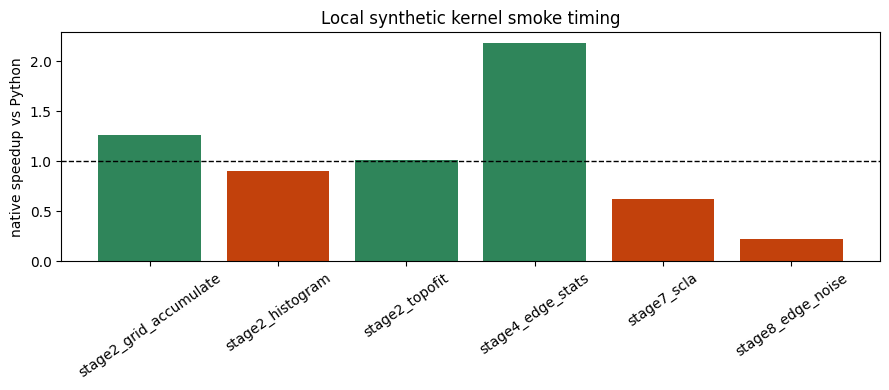

In [9]:
print("Step 8 - focused kernel timing plot")
plot_data = bench.dropna(subset=["speedup_native_vs_python"])
fig, ax = plt.subplots(figsize=(9, 4))
if plot_data.empty:
    ax.text(0.5, 0.5, "No native timings available\nNo kernel speed claim justified", ha="center", va="center", fontsize=13)
    ax.set_axis_off()
    print("Verdict: no Python/native kernel speed plot can be interpreted because native timings were skipped.")
else:
    colors = ["#2f855a" if value > 1.0 else "#c2410c" for value in plot_data["speedup_native_vs_python"]]
    ax.bar(plot_data["kernel"], plot_data["speedup_native_vs_python"], color=colors)
    ax.axhline(1.0, color="black", linewidth=1, linestyle="--")
    ax.set_ylabel("native speedup vs Python")
    ax.set_title("Local synthetic kernel smoke timing")
    ax.tick_params(axis="x", rotation=35)
    print("Verdict: plotted bars are local synthetic smoke timings, not publishable benchmark evidence.")
fig.tight_layout()
plt.show()


## 9. Final decision from this notebook

The final decision combines the evidence above. It should be conservative: failed or interrupted commands do not support claims.


In [10]:
print("Step 9 - final decision")
collected_native = bench["native_ms"].notna().any()
all_collected_parity_passed = bool((bench.loc[bench["native_ms"].notna(), "parity"] == "PASS").all()) if collected_native else False
any_native_faster = bool((bench["speedup_native_vs_python"] > 1.0).any()) if collected_native else False

print(f"Verifier smoke check passed: {verify_report.ok}")
print(f"Full audit passed here: {audit_ok}")
print(f"Completed Stage 1 benchmark passed: {benchmark_stage1_ok}")
print(f"Broad benchmark speed claim supported: {benchmark_full_speed_claim}")
print(f"Focused native timings collected: {collected_native}")
print(f"Focused native parity passed where collected: {all_collected_parity_passed}")
print(f"At least one focused native smoke timing was faster: {any_native_faster}")
print()
if audit_ok and benchmark_full_speed_claim:
    print("Final verdict: project-level parity and speed claims are supported by completed audit and benchmark evidence.")
else:
    print("Final verdict: do not claim project-level parity or speed improvement from this notebook run.")
    print("Supported claim: the API is demonstrated, verifier smoke check passes, and the completed Stage 1 benchmark is shown exactly as measured.")


Step 9 - final decision
Verifier smoke check passed: True
Full audit passed here: False
Completed Stage 1 benchmark passed: True
Broad benchmark speed claim supported: False
Focused native timings collected: True
Focused native parity passed where collected: True
At least one focused native smoke timing was faster: True

Final verdict: do not claim project-level parity or speed improvement from this notebook run.
Supported claim: the API is demonstrated, verifier smoke check passes, and the completed Stage 1 benchmark is shown exactly as measured.
